<a href="https://colab.research.google.com/github/JusthackOne/Alarm/blob/main/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Функции (3 балла)

##1.1

Постройте график функции и её производной первого порядка. Также найдите точки экстремума функции, отметьте их на графике другим цветом. Вычисления проведите вручную и приложите скрин расчетов.

$f(x) = (x^2-2x)ln(x)-1.5x^2+4x$


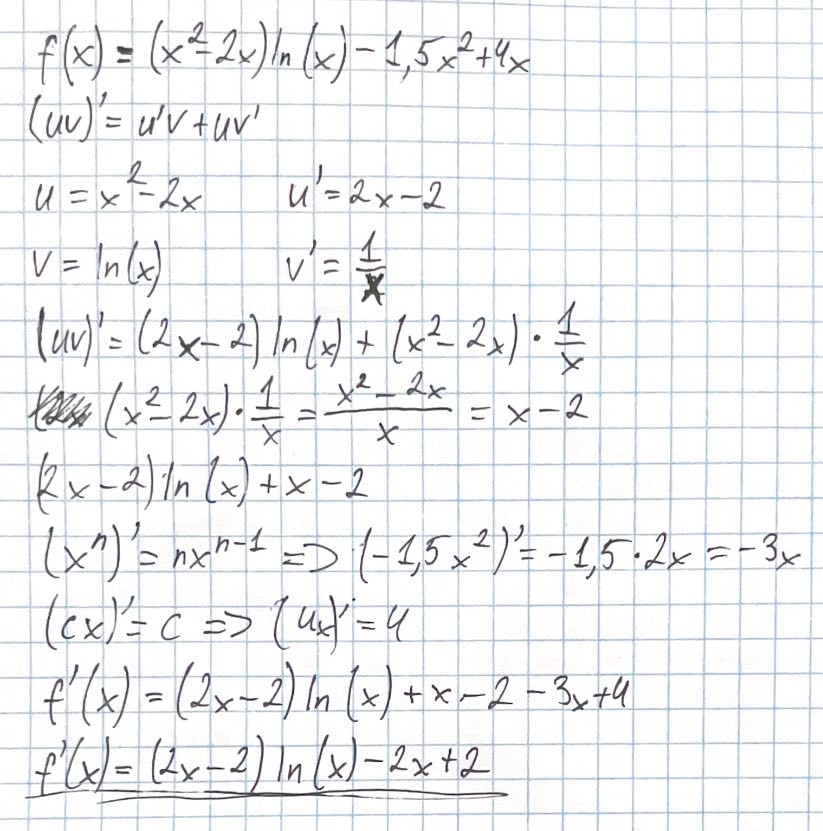

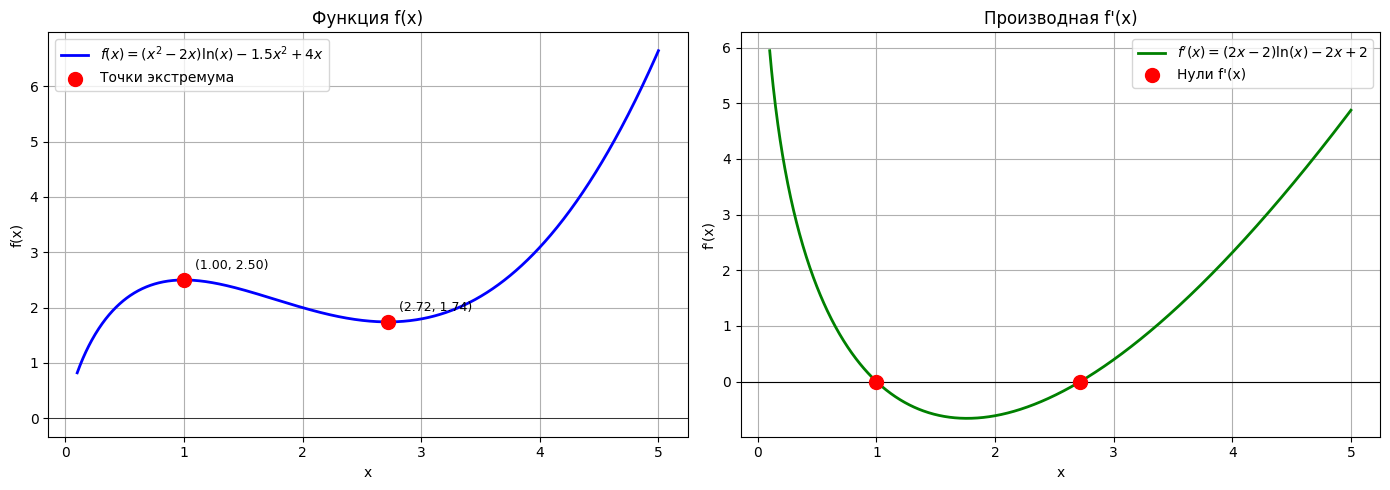

Точки экстремума:
  x = 1.0000,  f(x) = 2.5000
  x = 2.7183,  f(x) = 1.7420


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

def f(x):
    return (x**2 - 2*x) * np.log(x) - 1.5*x**2 + 4*x

def f_dx(x):
    # f'(x) = (2x-2)*ln(x) + (x^2-2x)/x - 3x + 4
    return (2*x - 2) * np.log(x) + (x**2 - 2*x) / x - 3*x + 4

x_values = np.linspace(0.1, 5, 1000)

# Поиск точек экстремума: нули производной
dx_vals = f_dx(x_values)
sign_changes = np.where(np.diff(np.sign(dx_vals)))[0]
extrema_x = []
for idx in sign_changes:
    try:
        root = brentq(f_dx, x_values[idx], x_values[idx+1])
        extrema_x.append(root)
    except Exception:
        pass
extrema_x = np.array(extrema_x)
extrema_y = f(extrema_x)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График функции
axes[0].plot(x_values, f(x_values), 'b-', linewidth=2,
             label=r'$f(x) = (x^2-2x)\ln(x) - 1.5x^2 + 4x$')
axes[0].scatter(extrema_x, extrema_y, color='red', zorder=5, s=100,
                label='Точки экстремума')
for ex, ey in zip(extrema_x, extrema_y):
    axes[0].annotate(f'({ex:.2f}, {ey:.2f})', (ex, ey),
                     textcoords='offset points', xytext=(8, 8), fontsize=9)
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].set_title('Функция f(x)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)')
axes[0].legend(); axes[0].grid(True)

# График производной
axes[1].plot(x_values, f_dx(x_values), 'g-', linewidth=2,
             label=r"$f'(x) = (2x-2)\ln(x) - 2x + 2$")
axes[1].scatter(extrema_x, np.zeros_like(extrema_x), color='red', zorder=5,
                s=100, label="Нули f'(x)")
axes[1].axhline(0, color='k', linewidth=0.8)
axes[1].set_title("Производная f'(x)")
axes[1].set_xlabel('x'); axes[1].set_ylabel("f'(x)")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

print("Точки экстремума:")
for ex, ey in zip(extrema_x, extrema_y):
    print(f"  x = {ex:.4f},  f(x) = {ey:.4f}")

##1.2

Найдите частные производные функции $f(x, y, z) = 15x^2 + exp(x^2 + y^3)*cos(z)$ с помощью [SymPy](https://www.geeksforgeeks.org/python-sympy-diff-method/)

In [ ]:
import sympy as sp

x, y, z = sp.symbols('x y z')

f = 15*x**2 + sp.exp(x**2 + y**3) * sp.cos(z)

df_dx = sp.diff(f, x)
df_dy = sp.diff(f, y)
df_dz = sp.diff(f, z)

print("f(x, y, z) =", f)
print()
print("∂f/∂x =", df_dx)
print()
print("∂f/∂y =", df_dy)
print()
print("∂f/∂z =", df_dz)

f(x, y, z) = 15*x**2 + exp(x**2 + y**3)*cos(z)

∂f/∂x = 2*x*exp(x**2 + y**3)*cos(z) + 30*x

∂f/∂y = 3*y**2*exp(x**2 + y**3)*cos(z)

∂f/∂z = -exp(x**2 + y**3)*sin(z)


##2

Не всегда значения функций возможно рассчитать напрямую, однако их можно вычислить приближенно, используя, например, ряды Тейлора. Реализуйте расчет $e^x$. Сравните значения, получаемые с различной точностью приближения (5, 10, 15), с numpy-реализацией. Постройте график, отобразив на нём все четыре линии.

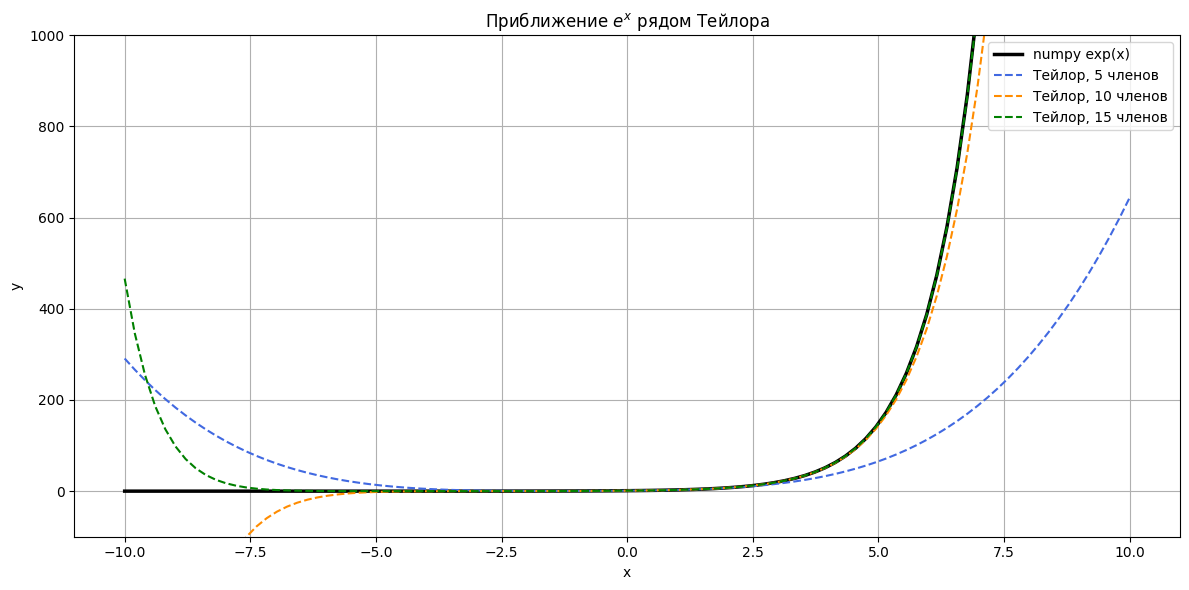

Сравнение значений в точке x = 3:
  numpy:         20.08553692
  Тейлор ( 5):  16.37500000   ошибка: 3.71e+00
  Тейлор (10):  20.06339286   ошибка: 2.21e-02
  Тейлор (15):  20.08552346   ошибка: 1.35e-05


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial

x_values = np.linspace(-10, 10, 100)

def taylor_exp(x, n_terms):
    """Приближение e^x рядом Тейлора с n_terms членами."""
    result = np.zeros_like(x, dtype=float)
    for k in range(n_terms):
        result = result + x**k / factorial(k)
    return result

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(x_values, np.exp(x_values), 'k-', linewidth=2.5, label='numpy exp(x)')

colors = ['royalblue', 'darkorange', 'green']
for n_terms, color in zip([5, 10, 15], colors):
    y_approx = np.clip(taylor_exp(x_values, n_terms), -1000, 30000)
    ax.plot(x_values, y_approx, '--', color=color, linewidth=1.5,
            label=f'Тейлор, {n_terms} членов')

ax.set_ylim(-100, 1000)
ax.set_title(r'Приближение $e^x$ рядом Тейлора')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()

x_test = 3
print(f"Сравнение значений в точке x = {x_test}:")
print(f"  numpy:         {np.exp(x_test):.8f}")
for n_terms in [5, 10, 15]:
    approx = sum(x_test**k / factorial(k) for k in range(n_terms))
    print(f"  Тейлор ({n_terms:2d}):  {approx:.8f}   ошибка: {abs(approx - np.exp(x_test)):.2e}")

##3

Рассмотрите две следующие функции, часто использующиеся как функции потерь (то есть они помогают оценить качество предсказаний модели).

$MAE (Mean\ Absolute\ Error) = \frac{1}{n} \sum_{i=1}^{n} |y_i - \widehat{y}_i|$

$MSE (Mean\ Squared\ Error) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \widehat{y}_i)^2$

Письменно ответьте на вопросы:

1. Какая проблема присуща MAE с точки зрения дифференцирования?

2. Если в качестве $\widehat{y}_i$ всегда будет предсказываться константное значение, каким оно должно быть, чтобы минимизировать значение каждой из функций?


Ответ:

1) В формуле MAE стоит модуль $|y_i - \widehat{y}_i|$. Модуль не дифференцируем в точке ноля — то есть в момент когда предсказание совпадает с реальным значением, производной не существует. Из-за этого градиентный спуск не знает в какую сторону двигаться в этой точке и ломается.

2) Для MSE — оптимальная константа это среднее всех значений. Если берёшь производную MSE по константе и приравниваешь к нулю, получается именно среднее.
Для MAE — оптимальная константа это медиана всех значений. Медиана минимизирует сумму абсолютных отклонений — это математически доказанный факт.

# Матрицы. Векторы (2 балла)

##1

Реализуйте следующие паттерны. Не используйте циклы! Все матрицы квадратные со стороной длины n. Примеры приведены для n=5.

1. Шахматная доска
```
[[0. 1. 0. 1. 0.]
 [1. 0. 1. 0. 1.]
 [0. 1. 0. 1. 0.]
 [1. 0. 1. 0. 1.]
 [0. 1. 0. 1. 0.]]
 ```
2. Полоса шириной 3 относительно главной диагонали
```
[[1. 1. 0. 0. 0.]
 [1. 1. 1. 0. 0.]
 [0. 1. 1. 1. 0.]
 [0. 0. 1. 1. 1.]
 [0. 0. 0. 1. 1.]]
 ```
3. Кайма из единиц
```
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
 ```
4. Полосы
```
[[0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0.]]
 ```
5. Верхний треугольник
```
[[1. 1. 1. 1. 1.]
 [0. 1. 1. 1. 1.]
 [0. 0. 1. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 1.]]
 ```


In [ ]:
import numpy as np

n = 5
i_idx, j_idx = np.indices((n, n))

# 1. Шахматная доска
chess = ((i_idx + j_idx) % 2).astype(float)
print("1. Шахматная доска:")
print(chess)

# 2. Полоса шириной 3 вдоль главной диагонали
band = (np.abs(i_idx - j_idx) <= 1).astype(float)
print("\n2. Полоса шириной 3:")
print(band)

# 3. Кайма из единиц
frame = np.zeros((n, n))
frame[0, :] = frame[-1, :] = frame[:, 0] = frame[:, -1] = 1.0
print("\n3. Кайма:")
print(frame)

# 4. Горизонтальные полосы (нечётные строки — единицы)
stripes = (i_idx % 2 == 1).astype(float)
print("\n4. Полосы:")
print(stripes)

# 5. Верхний треугольник
upper = np.triu(np.ones((n, n)))
print("\n5. Верхний треугольник:")
print(upper)

1. Шахматная доска:
[[0. 1. 0. 1. 0.]
 [1. 0. 1. 0. 1.]
 [0. 1. 0. 1. 0.]
 [1. 0. 1. 0. 1.]
 [0. 1. 0. 1. 0.]]

2. Полоса шириной 3:
[[1. 1. 0. 0. 0.]
 [1. 1. 1. 0. 0.]
 [0. 1. 1. 1. 0.]
 [0. 0. 1. 1. 1.]
 [0. 0. 0. 1. 1.]]

3. Кайма:
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]

4. Полосы:
[[0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0.]]

5. Верхний треугольник:
[[1. 1. 1. 1. 1.]
 [0. 1. 1. 1. 1.]
 [0. 0. 1. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 1.]]


##2

Пусть дан вектор следующего вида. Преобразуйте его, чтобы получить две матрицы: первая должна содержать одинаковые значения column-wise (столбец целиком из нулей, столбец целиком из единиц и так далее), а вторая - row-wise. Не используйте циклы.

In [ ]:
n = 5
vector = np.hstack([[i for i in range(n)] for _ in range(n)])  # также существуют vstack и dstack
print(vector)

[0 1 2 3 4 0 1 2 3 4 0 1 2 3 4 0 1 2 3 4 0 1 2 3 4]


In [ ]:
import numpy as np

n = 5
vector = np.hstack([[i for i in range(n)] for _ in range(n)])
print("Исходный вектор:", vector)

# Column-wise: столбец j целиком = j
col_matrix = np.tile(np.arange(n), (n, 1))
print("\nColumn-wise (столбцы из одинаковых значений):")
print(col_matrix)

# Row-wise: строка i целиком = i
row_matrix = np.tile(np.arange(n).reshape(-1, 1), (1, n))
print("\nRow-wise (строки из одинаковых значений):")
print(row_matrix)

Исходный вектор: [0 1 2 3 4 0 1 2 3 4 0 1 2 3 4 0 1 2 3 4 0 1 2 3 4]

Column-wise (столбцы из одинаковых значений):
[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]

Row-wise (строки из одинаковых значений):
[[0 0 0 0 0]
 [1 1 1 1 1]
 [2 2 2 2 2]
 [3 3 3 3 3]
 [4 4 4 4 4]]


# Введение в PyTorch (2 балла)

С точки зрения синтаксиса PyTorch похож на NumPy, основная разница заключается в том, что данный фреймворк предназначен для автоматического расчета градиентов. [Вот тут](https://github.com/torch/torch7/wiki/Torch-for-Numpy-users) можно почитать про то, как соотносятся две эти библиотеки.

[Неплохой курс чисто про PyTorch](https://www.learnpytorch.io/)

[Документация PyTorch](https://pytorch.org/)

In [ ]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torchvision
from torchvision.transforms import transforms

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import nltk
from nltk import word_tokenize, sent_tokenize
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

##1

1. Создайте два вещественных тензора: $a$ размером (10, 2) и $b$ размером (, 20)

2. Создайте тензор c, являющийся тензором $b$, но размера (2, 2, 5)

3. Выведите первый столбец матрицы $a$ с помощью индексации

4. Создайте тензор $d$, являющийся тензором $b$, но размера (10, 2). Произведите все арифметические операции с тензорами $a$ и $d$

In [ ]:
import torch

# 1. Тензоры a (10,2) и b (20,)
a = torch.rand(10, 2)
b = torch.rand(20)
print("a shape:", a.shape)
print("b shape:", b.shape)

# 2. c = b с формой (2, 2, 5)
c = b.reshape(2, 2, 5)
print("c shape:", c.shape)

# 3. Первый столбец a
print("\nПервый столбец a (индексация [:, 0]):")
print(a[:, 0])

# 4. d = b с формой (10, 2); арифметика с a
d = b.reshape(10, 2)
print("\nd shape:", d.shape)
print("\na + d ="); print(a + d)
print("\na - d ="); print(a - d)
print("\na * d ="); print(a * d)
print("\na / d ="); print(a / d)

a shape: torch.Size([10, 2])
b shape: torch.Size([20])
c shape: torch.Size([2, 2, 5])

Первый столбец a (индексация [:, 0]):
tensor([0.7041, 0.1563, 0.9293, 0.8370, 0.3204, 0.1311, 0.9340, 0.0103, 0.3180,
        0.0517])

d shape: torch.Size([10, 2])

a + d =
tensor([[1.2713, 1.1567],
        [0.5028, 0.7318],
        [1.1866, 1.1713],
        [1.5597, 1.3762],
        [1.0000, 0.6255],
        [0.2562, 1.7720],
        [1.6020, 0.7564],
        [0.5958, 0.9971],
        [0.3461, 0.9381],
        [0.7903, 0.5181]])

a - d =
tensor([[ 0.1370, -0.4877],
        [-0.1901,  0.2449],
        [ 0.6719,  0.4429],
        [ 0.1144, -0.2377],
        [-0.3592,  0.0619],
        [ 0.0059,  0.0051],
        [ 0.2660,  0.3928],
        [-0.5753,  0.5845],
        [ 0.2899, -0.5697],
        [-0.6868, -0.4892]])

a * d =
tensor([[0.3994, 0.2750],
        [0.0542, 0.1189],
        [0.2392, 0.2939],
        [0.6049, 0.4594],
        [0.2177, 0.0969],
        [0.0164, 0.7850],
        [0.6240, 0.1044

## 2

1. Создайте тензор *целых чисел* `images` размерности (100, 200, 200, 3) (можно интерпретировать это как 100 картинок размера 200х200 с тремя цветовыми каналами, то есть 100 цветных изображений 200х200). Заполните его нулями  

2. Сделайте так, чтобы у $i$-ой по порядку картинки была нарисована белая полоса толщиной два пикселя в строках, которые соответствуют номеру картинки * 2. Например, у 3-ей по порядку картинки белая полоска будет занимать 6 и 7 строки, у 99 - 198 и 199. Сделать белую строку можно, записав в ячейки тензора число 255 (по всем трём каналам). Выведите несколько примеров с помощью `pyplot`  

3. Посчитайте среднее тензора `images` по 1-ой оси (по сути - средняя картинка), умножьте полученный тензор на 70. Нарисуйте с помощью `pyplot`, должна получиться серая картинка (при взятии среднего нужно привести тензор к float с помощью `.float()`, при отрисовке обратно к int с помощью `.int()`)

images shape: torch.Size([100, 200, 200, 3])


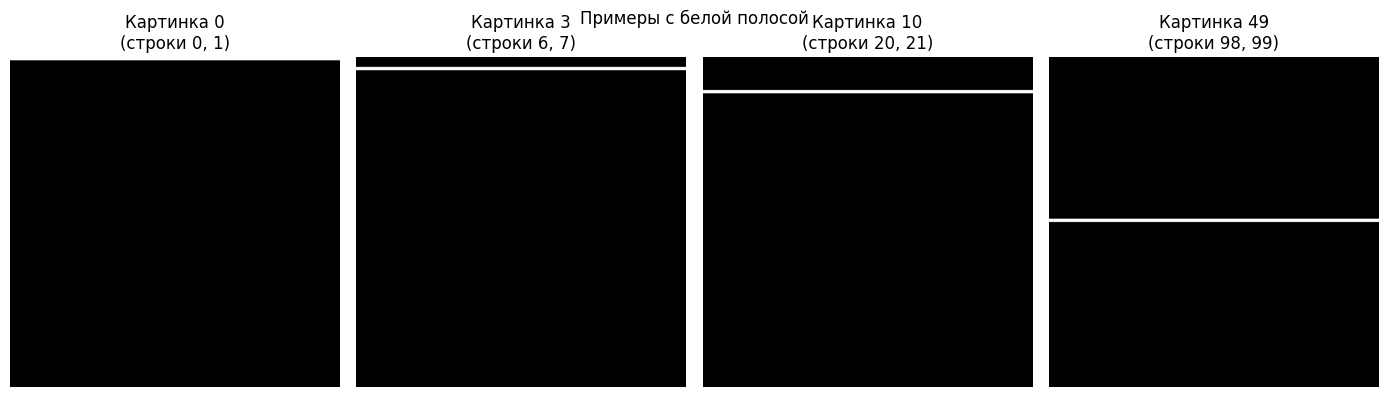

Средняя картинка shape: torch.Size([200, 200, 3])


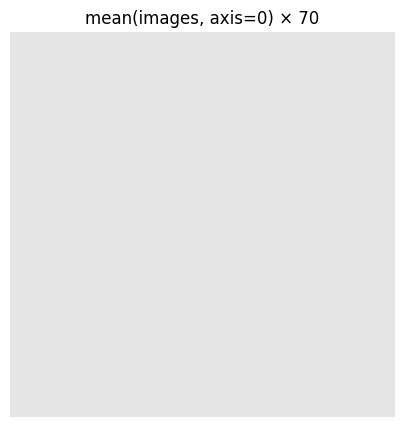

In [ ]:
import torch
import matplotlib.pyplot as plt

# 1. Тензор images (100, 200, 200, 3), целые, нули
images = torch.zeros(100, 200, 200, 3, dtype=torch.int32)
print("images shape:", images.shape)

# 2. Белые полосы: у картинки i строки [2i, 2i+1]
indices = torch.arange(100)
row1 = indices * 2
row2 = torch.clamp(row1 + 1, max=199)

for i in range(100):
    images[i, row1[i].item(), :, :] = 255
    images[i, row2[i].item(), :, :] = 255

# Несколько примеров
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, idx in zip(axes, [0, 3, 10, 49]):
    ax.imshow(images[idx].numpy())
    ax.set_title(f'Картинка {idx}\n(строки {idx*2}, {idx*2+1})')
    ax.axis('off')
plt.suptitle('Примеры с белой полосой')
plt.tight_layout()
plt.show()

# 3. Средняя картинка * 70
mean_img = (images.float().mean(dim=0) * 90).int()
print("Средняя картинка shape:", mean_img.shape)
plt.figure(figsize=(5, 5))
plt.imshow(mean_img.numpy())
plt.title('mean(images, axis=0) × 70')
plt.axis('off')
plt.show()

## 3

1. Смените среду выполнения на GPU (в Colab нажмите в меню сверху: `Runtime` -> `Change Runtime Type` -> `GPU`, где изначально стоит `None` (`Среда выполнение` - `Сменить среду выполнения`))

2. Объявите тензор $a$ размера (2, 3, 4) и тензор $b$ размера (1, 8, 3) на GPU, иницилизируйте их случайно равномерно (`.uniform_()`)

3. Измените форму тензора $b$, чтобы она совпадала с формой тензора $a$, получите тензор $c$.

4. Переместите тензоры $a$ и $c$ на CPU.

5. Объявите тензор `L = torch.mean((c - a) `**` 2)` и посчитайте градиент $L$ по $c$ ( то есть $\frac{\partial{L}}{\partial{c}})$. Выведите градиент $L$ по $c$. Также вычислите его вручную, чтобы проверить себя.

In [ ]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")

# 2. Тензоры a (2,3,4) и b (1,8,3) на device, равномерно
a = torch.empty(2, 3, 4, device=device).uniform_()
b = torch.empty(1, 8, 3, device=device).uniform_()
print("a shape:", a.shape)
print("b shape:", b.shape)

# 3. c = b reshape → (2, 3, 4)
c = b.reshape(2, 3, 4)
print("c shape:", c.shape)

# 4. a и c на CPU
a_cpu = a.cpu()
c_cpu = c.cpu().requires_grad_(True)

# 5. L = mean((c - a)^2), градиент dL/dc
L = torch.mean((c_cpu - a_cpu) ** 2)
L.backward()

print("\nL =", L.item())
print("\ndL/dc (autograd):")
print(c_cpu.grad)

# Аналитически: dL/dc = 2*(c-a) / N
grad_manual = 2 * (c_cpu - a_cpu) / c_cpu.numel()
print("\ndL/dc (вручную):")
print(grad_manual.detach())

print("\nСовпадение:", torch.allclose(c_cpu.grad, grad_manual.detach(), atol=1e-6))

Устройство: cuda
a shape: torch.Size([2, 3, 4])
b shape: torch.Size([1, 8, 3])
c shape: torch.Size([2, 3, 4])

L = 0.15950243175029755

dL/dc (autograd):
tensor([[[-0.0501,  0.0330, -0.0316, -0.0407],
         [ 0.0116,  0.0052,  0.0558,  0.0104],
         [ 0.0022, -0.0140,  0.0314,  0.0754]],

        [[-0.0120, -0.0359, -0.0071,  0.0124],
         [-0.0393, -0.0359,  0.0331,  0.0229],
         [ 0.0133,  0.0542,  0.0288,  0.0060]]])

dL/dc (вручную):
tensor([[[-0.0501,  0.0330, -0.0316, -0.0407],
         [ 0.0116,  0.0052,  0.0558,  0.0104],
         [ 0.0022, -0.0140,  0.0314,  0.0754]],

        [[-0.0120, -0.0359, -0.0071,  0.0124],
         [-0.0393, -0.0359,  0.0331,  0.0229],
         [ 0.0133,  0.0542,  0.0288,  0.0060]]])

Совпадение: True


# Теория вероятностей (4 балла)

##1

Постройте графики плотности распределений для следующих распределений:

* Биномиальное распределение
* Геометрическое распределение
* Равномерное распределение
* Нормальное распределение
* Логнормальное распределение

Параметры распределений выберите произвольно. Подумайте, какие явления в реальном мире подчиняются тому или иному распределению.

Отобразите также следующие статистические показатели: выборочное среднее, мода, медиана, стандартное отклонение.

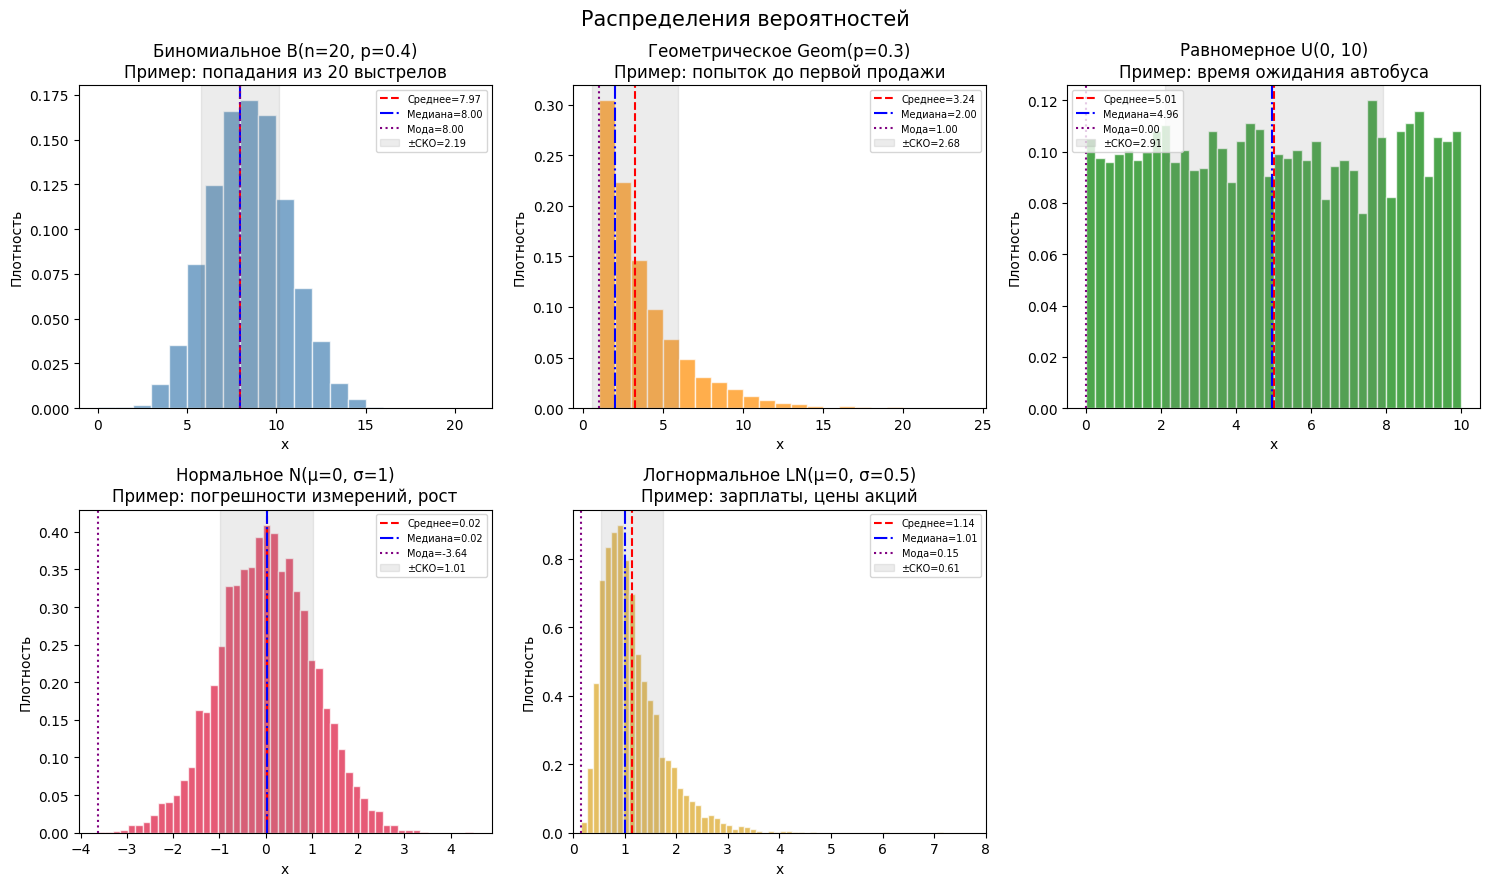

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

np.random.seed(42)
N = 5000
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Распределения вероятностей', fontsize=15)

def add_stats(ax, data):
    mean = np.mean(data)
    median = np.median(data)
    std = np.std(data)
    mode_val = stats.mode(data, keepdims=True).mode[0]
    ax.axvline(mean,     color='red',    linestyle='--', linewidth=1.5, label=f'Среднее={mean:.2f}')
    ax.axvline(median,   color='blue',   linestyle='-.', linewidth=1.5, label=f'Медиана={median:.2f}')
    ax.axvline(mode_val, color='purple', linestyle=':',  linewidth=1.5, label=f'Мода={mode_val:.2f}')
    ax.axvspan(mean-std, mean+std, alpha=0.15, color='gray', label=f'±СКО={std:.2f}')
    ax.legend(fontsize=7)

# 1. Биномиальное
data = np.random.binomial(n=20, p=0.4, size=N)
ax = axes[0, 0]
ax.hist(data, bins=range(22), density=True, color='steelblue', alpha=0.7, edgecolor='white')
add_stats(ax, data)
ax.set_title('Биномиальное B(n=20, p=0.4)\nПример: попадания из 20 выстрелов')
ax.set_xlabel('x'); ax.set_ylabel('Плотность')

# 2. Геометрическое
data = np.random.geometric(p=0.3, size=N)
ax = axes[0, 1]
ax.hist(data, bins=range(1, 25), density=True, color='darkorange', alpha=0.7, edgecolor='white')
add_stats(ax, data)
ax.set_title('Геометрическое Geom(p=0.3)\nПример: попыток до первой продажи')
ax.set_xlabel('x'); ax.set_ylabel('Плотность')

# 3. Равномерное
data = np.random.uniform(0, 10, size=N)
ax = axes[0, 2]
ax.hist(data, bins=40, density=True, color='green', alpha=0.7, edgecolor='white')
add_stats(ax, data)
ax.set_title('Равномерное U(0, 10)\nПример: время ожидания автобуса')
ax.set_xlabel('x'); ax.set_ylabel('Плотность')

# 4. Нормальное
data = np.random.normal(0, 1, size=N)
ax = axes[1, 0]
ax.hist(data, bins=50, density=True, color='crimson', alpha=0.7, edgecolor='white')
add_stats(ax, data)
ax.set_title('Нормальное N(μ=0, σ=1)\nПример: погрешности измерений, рост')
ax.set_xlabel('x'); ax.set_ylabel('Плотность')

# 5. Логнормальное
data = np.random.lognormal(0, 0.5, size=N)
ax = axes[1, 1]
ax.hist(data, bins=60, density=True, color='goldenrod', alpha=0.7, edgecolor='white')
add_stats(ax, data)
ax.set_title('Логнормальное LN(μ=0, σ=0.5)\nПример: зарплаты, цены акций')
ax.set_xlabel('x'); ax.set_ylabel('Плотность')
ax.set_xlim(0, 8)

axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

Подумайте, в каких случаях медиана предпочтительнее среднего при расчете "средней температуры по больнице". Какие модификации можно было бы произвести для формулы среднего или для выборки, чтобы среднее значение стало более репрезентативно в подобных случаях? Напишите ответ.

Ответ:
Медиана предпочтительнее когда в данных есть выбросы — единичные значения которые сильно отличаются от остальных. Среднее на них реагирует сильно, медиана — почти не реагирует.
Есть несколько способов улучшить среднее чтобы оно тоже не реагировало на выбросы:
1. Усечённое среднее — просто выкидываем крайние значения перед подсчётом.
2. Взвешенное среднее — типичным значениям даём больший вес, выбросам меньший.
3. Почистить выборку — перед подсчётом просто удалить аномальные значения.


##2 (2 балла)

1000 человек бросают монетку. Каждый бросил 10 раз подряд.

 1. Какова вероятность того, что хотя бы у одного человека монетка выпала 10 раз подряд той же самой стороной (орлом или решкой)?
 2. Какова вероятность того, что хотя бы у одного человека монетка выпала 8 раз подряд той же самой стороной (орлом или решкой)?
 3. Какова вероятность того, что ровно у троих человек из 1000 монетка выпала 10 раз подряд той же самой стороной (орлом или решкой)?

 Рассчитайте вероятности, а также смоделируйте ситуацию и оцените эмпирическое распределение.

In [ ]:
import numpy as np
from scipy.stats import binom

np.random.seed(42)

n_people, n_tosses = 1000, 10

# P(один человек бросит все 10 одинаково) = 2 * (1/2)^10
p_10_same = 2 * (0.5 ** 10)
print(f"P(10 одинаковых подряд) = {p_10_same:.6f} = 1/{int(1/p_10_same)}")

# Q1: P(хотя бы 1 из 1000 — 10 одинаковых)
p_at_least_one_10 = 1 - (1 - p_10_same) ** n_people
print(f"\n[Q1] P(≥1 с 10 подряд) = {p_at_least_one_10:.6f}")

# Q2: P(хотя бы 1 из 1000 — 8 одинаковых подряд) — оценка симуляцией
def max_run(tosses):
    """Максимальная длина одинаковой серии."""
    max_r = cur_r = 1
    for i in range(1, len(tosses)):
        cur_r = cur_r + 1 if tosses[i] == tosses[i-1] else 1
        max_r = max(max_r, cur_r)
    return max_r

M = 100_000
count_8 = sum(1 for _ in range(M)
              if max_run(np.random.randint(0, 2, n_tosses)) >= 8)
p_8_same = count_8 / M
p_at_least_one_8 = 1 - (1 - p_8_same) ** n_people
print(f"\nP(один человек — ≥8 одинаковых) ≈ {p_8_same:.5f}")
print(f"[Q2] P(≥1 с 8 подряд)           ≈ {p_at_least_one_8:.6f}")

# Q3: P(ровно 3 из 1000 — 10 подряд) — биномиальное
p_exactly_3 = binom.pmf(3, n_people, p_10_same)
print(f"\n[Q3] P(ровно 3 с 10 подряд) = {p_exactly_3:.8f}")

# Симуляция всех трёх вопросов
M_exp = 5_000
cnt_q1 = cnt_q2 = cnt_q3 = 0

for _ in range(M_exp):
    tosses_all = np.random.randint(0, 2, (n_people, n_tosses))
    runs_10 = sum(max_run(tosses_all[i]) >= 10 for i in range(n_people))
    runs_8  = sum(max_run(tosses_all[i]) >=  8 for i in range(n_people))
    if runs_10 >= 1: cnt_q1 += 1
    if runs_8  >= 1: cnt_q2 += 1
    if runs_10 == 3: cnt_q3 += 1

print(f"\nСимуляция ({M_exp} экспериментов × {n_people} человек):")
print(f"  Q1 — теория: {p_at_least_one_10:.4f},  эмпирика: {cnt_q1/M_exp:.4f}")
print(f"  Q2 — теория: {p_at_least_one_8:.4f},  эмпирика: {cnt_q2/M_exp:.4f}")
print(f"  Q3 — теория: {p_exactly_3:.6f},  эмпирика: {cnt_q3/M_exp:.6f}")

P(10 одинаковых подряд) = 0.001953 = 1/512

[Q1] P(≥1 с 10 подряд) = 0.858440

P(один человек — ≥8 одинаковых) ≈ 0.01611
[Q2] P(≥1 с 8 подряд)           ≈ 1.000000

[Q3] P(ровно 3 с 10 подряд) = 0.17628739

Симуляция (5000 экспериментов × 1000 человек):
  Q1 — теория: 0.8584,  эмпирика: 0.8576
  Q2 — теория: 1.0000,  эмпирика: 1.0000
  Q3 — теория: 0.176287,  эмпирика: 0.168200


##3

В магазин поступила новая продукция с трех предприятий. Процентный состав этой продукции следующий: 20% - продукция первого предприятия, 30% - продукция второго предприятия, 50% - продукция третьего предприятия; далее, 10% продукции первого предприятия высшего сорта, на втором предприятии - 5% и на третьем - 20% продукции высшего сорта. Найти вероятность того, что случайно купленная новая продукция окажется высшего сорта. Если известно, что купленная продукция высшего сорта, какова вероятность, что она была куплена на втором предприятии?

Решите задачу в общем случае для N предприятий, где доля продукции каждого составляет $a_i$, а доля продукции высшего сорта на каждом составляет $b_i$. Напишите функцию, принимающую на вход два списка: a и b, а также n - номер предприятия, для которого необходимо узнать вероятность, что продукция высшего сорта была куплена именно на нём (нумерация с единицы). Функция должна возвращать две вероятности.

In [ ]:
import numpy as np

def bayes_quality(a, b, n):
    """
    Полная вероятность и формула Байеса.

    a : список долей продукции каждого предприятия (sum = 1)
    b : список долей высшего сорта на каждом предприятии
    n : номер предприятия (нумерация с 1)

    Возвращает:
        p_premium         — P(высший сорт)
        p_plant_n_given_h — P(предприятие n | высший сорт)
    """
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)

    # Полная вероятность: P(H) = Σ P(A_i) * P(H|A_i)
    p_premium = np.dot(a, b)

    # Формула Байеса: P(A_n|H) = P(A_n)*P(H|A_n) / P(H)
    p_plant_n_given_h = a[n - 1] * b[n - 1] / p_premium

    return p_premium, p_plant_n_given_h

# Данные задачи
a = [0.20, 0.30, 0.50]
b = [0.10, 0.05, 0.20]

print("=== Задача (N=3 предприятия) ===")
p_total, p2 = bayes_quality(a, b, n=2)
print(f"P(высший сорт)                   = {p_total:.4f}")
print(f"P(2-е предприятие | высший сорт) = {p2:.4f}")

print("\nВероятности для каждого предприятия:")
total_check = 0
for n_i in range(1, len(a) + 1):
    _, p_ni = bayes_quality(a, b, n_i)
    total_check += p_ni
    print(f"  P(предприятие {n_i} | высший сорт) = {p_ni:.4f}")
print(f"  Сумма (должна быть 1): {total_check:.4f}")

=== Задача (N=3 предприятия) ===
P(высший сорт)                   = 0.1350
P(2-е предприятие | высший сорт) = 0.1111

Вероятности для каждого предприятия:
  P(предприятие 1 | высший сорт) = 0.1481
  P(предприятие 2 | высший сорт) = 0.1111
  P(предприятие 3 | высший сорт) = 0.7407
  Сумма (должна быть 1): 1.0000


# Методы оптимизации (3 балла)



(Задание взято у Яндекса)

Дана функция $f(x) = (a\sin(x) + b\ln(x))^2 + cx^2$ и файл, содержащий пары (x, f(x)). Необходимо с точностью до трёх знаков после запятой подобрать коэффициенты a, b, c исходной функции. Для решения задачи предлагается использовать градиентный спуск и функцию потерь MSE.

P.S. на предоставленном наборе данных возможно получить MSE < 0.00001, ориентируйтесь на эту цифру.

In [ ]:
!gdown 1P5REbDVMtoHk_EPOaXzFWym2sMKhhbg3

Downloading...
From: https://drive.google.com/uc?id=1P5REbDVMtoHk_EPOaXzFWym2sMKhhbg3
To: /content/data.txt
100% 27.0k/27.0k [00:00<00:00, 43.7MB/s]


In [ ]:
with open('data.txt', 'r') as file:
    x_data = []
    y_data = []
    for para in eval(file.read()):
        x_data.append(para[0])
        y_data.append(para[1])
x_data = np.array(x_data)
y_data = np.array(y_data)

Epoch     0: MSE=1582.37389037  a=1.010  b=1.010  c=0.510
Epoch  1000: MSE=0.04356662  a=3.140  b=2.727  c=3.976
Epoch  2000: MSE=0.00000000  a=3.142  b=2.718  c=4.000
Epoch  3000: MSE=0.00000000  a=3.142  b=2.718  c=4.000
Epoch  4000: MSE=0.00000000  a=3.142  b=2.718  c=4.000
Epoch  5000: MSE=0.00000000  a=3.142  b=2.718  c=4.000
Epoch  6000: MSE=0.00000000  a=3.142  b=2.718  c=4.000
Epoch  7000: MSE=0.00000000  a=3.142  b=2.718  c=4.000

=== Результат ===
a = 3.142
b = 2.718
c = 4.000
MSE = 0.00000000


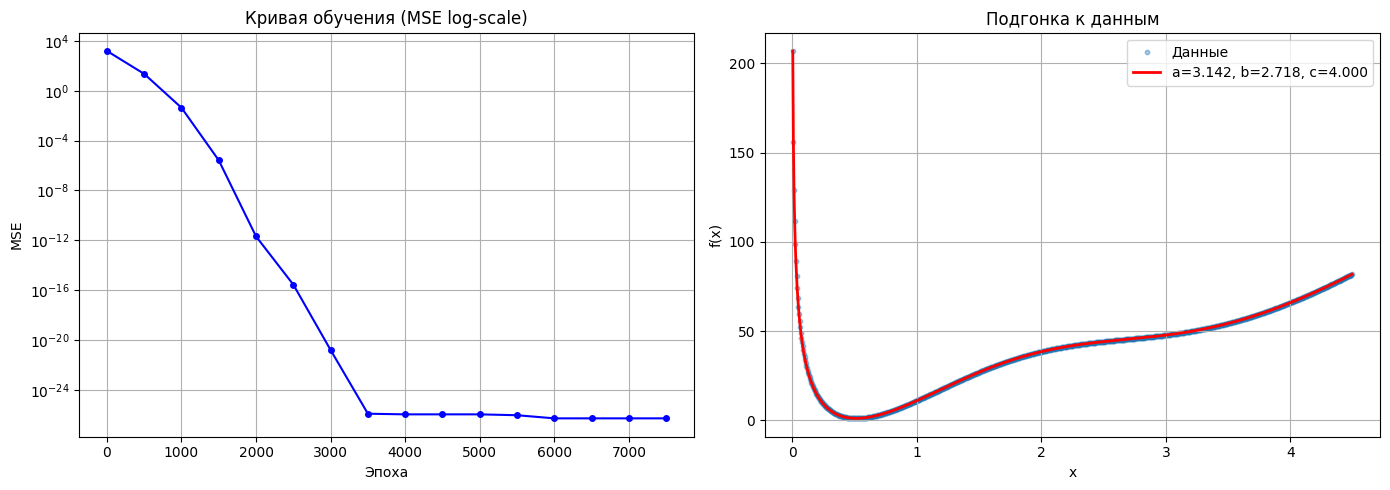

In [ ]:
import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

# x_data и y_data загружены из data.txt выше
x_t = torch.tensor(x_data, dtype=torch.float64)
y_t = torch.tensor(y_data, dtype=torch.float64)

# Параметры для подбора
a = torch.tensor([1.0], dtype=torch.float64, requires_grad=True)
b = torch.tensor([1.0], dtype=torch.float64, requires_grad=True)
c = torch.tensor([0.5], dtype=torch.float64, requires_grad=True)

def model(x, a, b, c):
    return (a * torch.sin(x) + b * torch.log(x))**2 + c * x**2

optimizer = optim.Adam([a, b, c], lr=0.01)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)

losses = []
n_epochs = 8000

for epoch in range(n_epochs):
    optimizer.zero_grad()
    loss = torch.mean((model(x_t, a, b, c) - y_t) ** 2)
    loss.backward()
    optimizer.step()
    scheduler.step()

    if epoch % 500 == 0:
        losses.append(loss.item())
        if epoch % 1000 == 0:
            print(f"Epoch {epoch:5d}: MSE={loss.item():.8f}  "
                  f"a={a.item():.3f}  b={b.item():.3f}  c={c.item():.3f}")

final_mse = torch.mean((model(x_t, a, b, c) - y_t)**2).item()
print(f"\n=== Результат ===")
print(f"a = {a.item():.3f}")
print(f"b = {b.item():.3f}")
print(f"c = {c.item():.3f}")
print(f"MSE = {final_mse:.8f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(0, n_epochs, 500), losses, 'b-o', markersize=4)
axes[0].set_yscale('log')
axes[0].set_title('Кривая обучения (MSE log-scale)')
axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('MSE')
axes[0].grid(True)

with torch.no_grad():
    y_pred = model(x_t, a, b, c).numpy()

sort_idx = np.argsort(x_data)
axes[1].scatter(x_data, y_data, s=10, alpha=0.4, label='Данные')
axes[1].plot(x_data[sort_idx], y_pred[sort_idx], 'r-', linewidth=2,
             label=f'a={a.item():.3f}, b={b.item():.3f}, c={c.item():.3f}')
axes[1].set_title('Подгонка к данным')
axes[1].set_xlabel('x'); axes[1].set_ylabel('f(x)')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()